# EDA 02 — Precio y características

**Dataset:** `data/processed/propiedades_argenprop_curado.csv`.

**Objetivos de este notebook:**
1. Analizar la distribución del target `precio_usd` y sus valores atípicos.
2. Relacionar el precio con las características (tipo, barrio, superficie, ambientes, dormitorios, antigüedad, expensas).
3. Explorar correlaciones entre variables numéricas.
4. Dejar conclusiones accionables para feature engineering (fase 4).

## Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RUTA_DATASET = Path("../data/processed/propiedades_argenprop_curado.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

In [2]:
df = pd.read_csv(RUTA_DATASET, low_memory=False)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 2,005 | Columnas: 32


## 1. Distribución del precio

In [3]:
df["precio_usd"].describe()

count    2.005000e+03
mean     2.007413e+05
std      1.909339e+05
min      0.000000e+00
25%      9.800000e+04
50%      1.480000e+05
75%      2.300000e+05
max      2.650000e+06
Name: precio_usd, dtype: float64

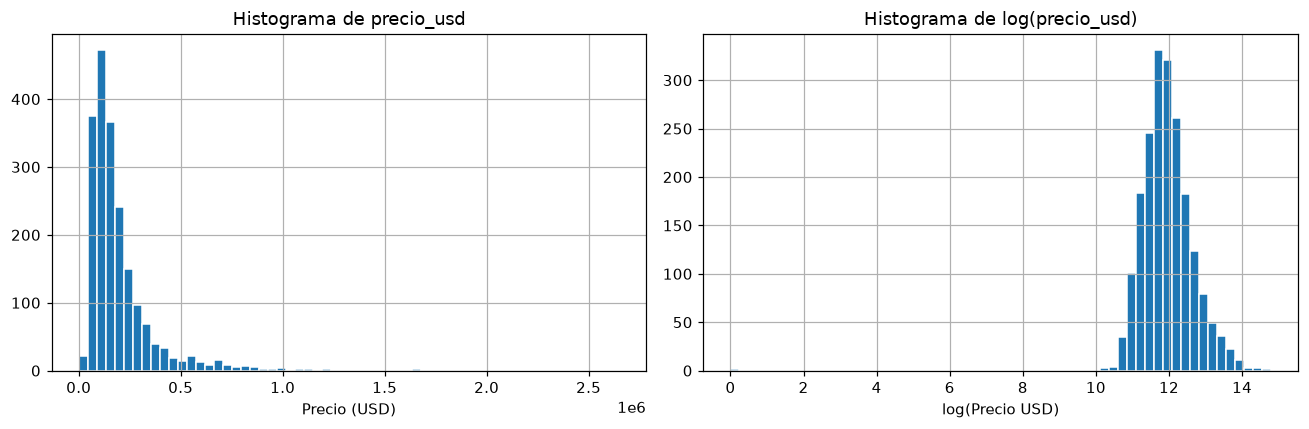

In [4]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["precio_usd"].hist(bins=60, ax=axes[0], edgecolor="white")
axes[0].set_title("Histograma de precio_usd")
axes[0].set_xlabel("Precio (USD)")

precio_pos = df.loc[df["precio_usd"] > 0, "precio_usd"]
np.log(precio_pos).hist(bins=60, ax=axes[1], edgecolor="white")
axes[1].set_title("Histograma de log(precio_usd)")
axes[1].set_xlabel("log(Precio USD)")
plt.tight_layout()
plt.show()

### 1.1 Valores atípicos

El precio mínimo es **0 USD** (imposible para una venta) y el máximo **2.65 M USD** (un orden de magnitud sobre la mediana). Se detectan outliers por el rango intercuartílico (IQR).

In [5]:
q1, q3 = df["precio_usd"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

atipicos = df["precio_usd"][(df["precio_usd"] < lim_inf) | (df["precio_usd"] > lim_sup)]
print(f"IQR: {iqr:,.0f}  |  límites: [{lim_inf:,.0f}, {lim_sup:,.0f}]")
print(f"Outliers por IQR: {len(atipicos)} ({len(atipicos) / len(df):.1%} del total)")
print(f"Precios <= 0: {(df['precio_usd'] <= 0).sum()}")

IQR: 132,000  |  límites: [-100,000, 428,000]
Outliers por IQR: 153 (7.6% del total)
Precios <= 0: 4


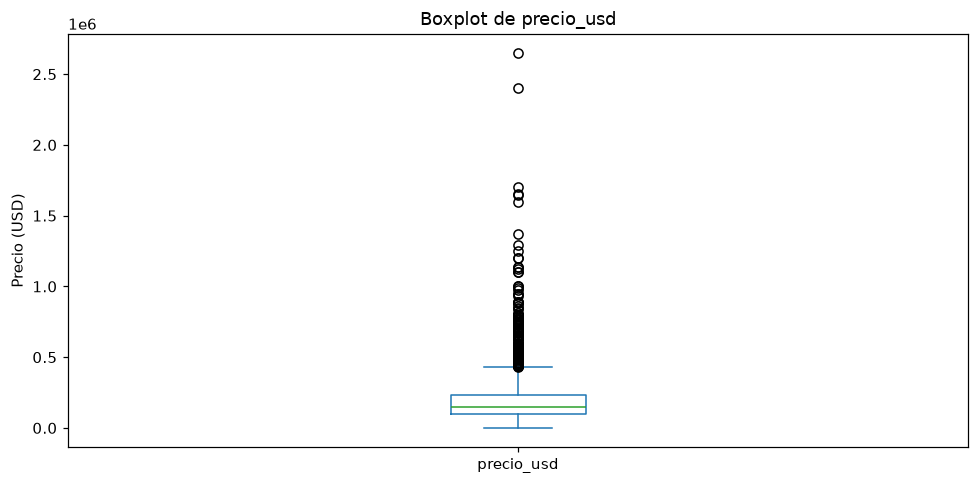

In [6]:
df["precio_usd"].plot.box()
plt.title("Boxplot de precio_usd")
plt.ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

## 2. Precio según características

### 2.1 Tipo de propiedad

C:\Users\Manaus\AppData\Local\Temp\ipykernel_10980\1216553923.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos_por_tipo, vert=False, tick_labels=tipos_orden)


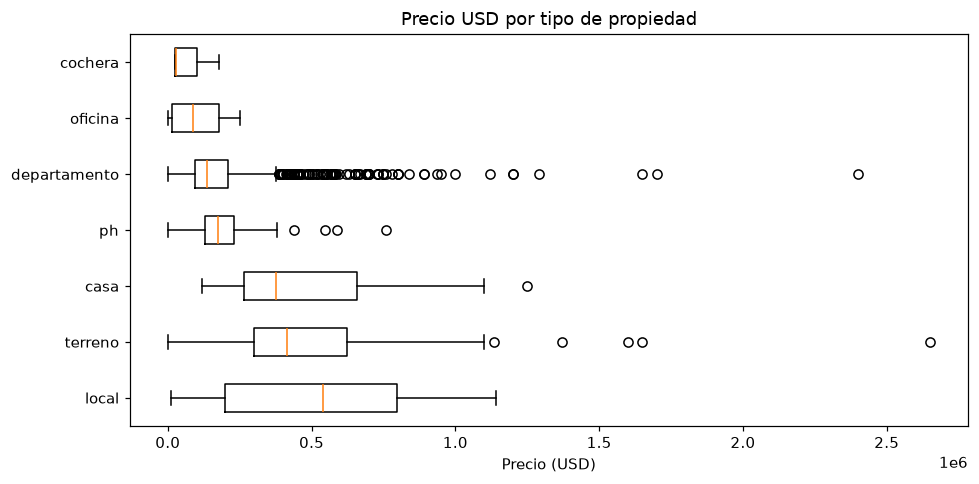

In [7]:
tipos_orden = df.groupby("tipo_propiedad")["precio_usd"].median().sort_values(ascending=False).index

datos_por_tipo = [df.loc[df["tipo_propiedad"] == t, "precio_usd"].dropna() for t in tipos_orden]
plt.boxplot(datos_por_tipo, vert=False, tick_labels=tipos_orden)
plt.title("Precio USD por tipo de propiedad")
plt.xlabel("Precio (USD)")
plt.tight_layout()
plt.show()

In [8]:
df.groupby("tipo_propiedad")["precio_usd"].agg(["count", "median", "mean"]).sort_values(
    "median", ascending=False
)

,count,median,mean
tipo_propiedad,,,
local,6,540000.0,533333.333333
terreno,54,415000.0,548166.703704
casa,72,377500.0,456068.055556
ph,133,176000.0,192093.984962
departamento,1732,138000.0,179342.307737
oficina,4,86500.0,105750.000000
cochera,3,27000.0,77000.000000


### 2.2 Barrio

La ubicación suele ser la variable más explicativa del precio inmobiliario. Se compara la mediana por barrio con el promedio general (línea punteada).

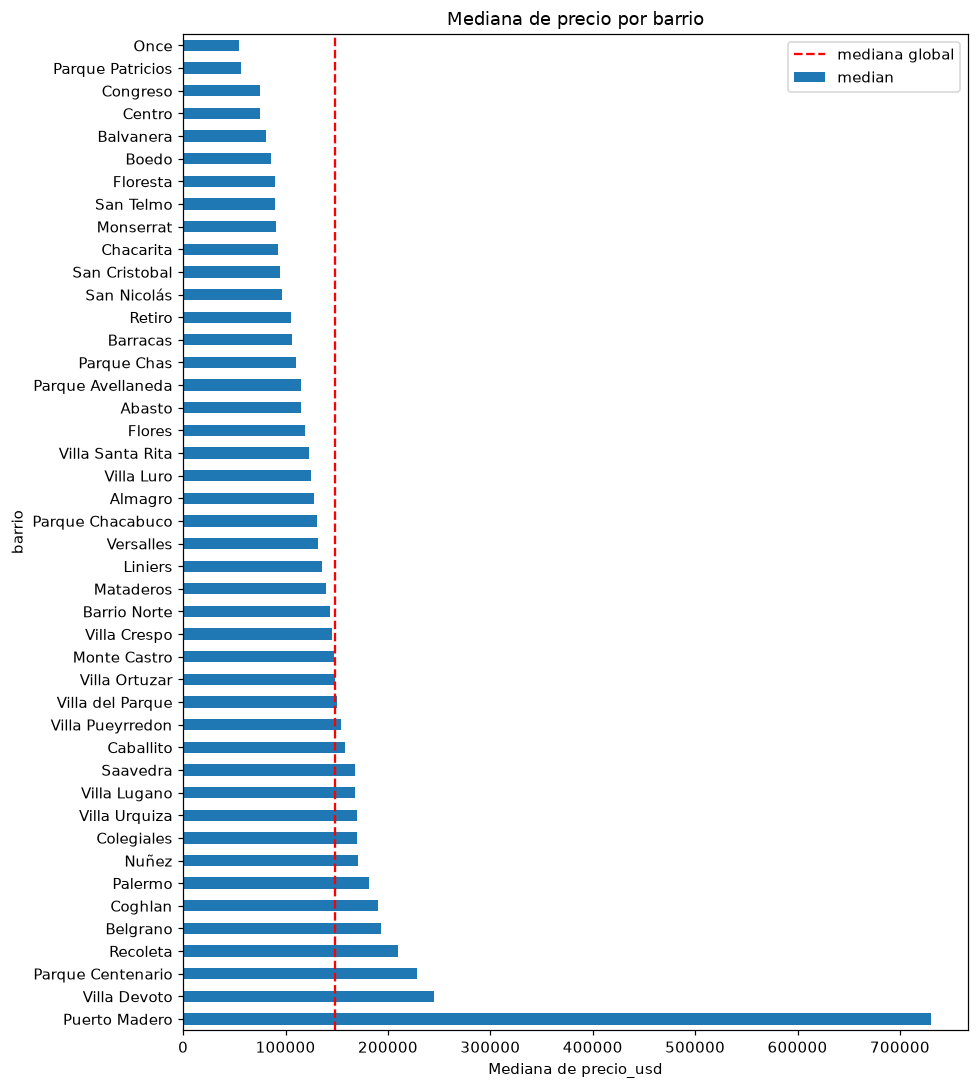

In [9]:
mediana_global = df["precio_usd"].median()

mediana_barrio = (
    df.groupby("barrio")["precio_usd"]
    .agg(["median", "count"])
    .sort_values("median", ascending=False)
)
mediana_barrio["median"].plot.barh(figsize=(9, 10))
plt.axvline(mediana_global, color="red", linestyle="--", label="mediana global")
plt.xlabel("Mediana de precio_usd")
plt.title("Mediana de precio por barrio")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
mediana_barrio.head(10)

,median,count
barrio,,
Puerto Madero,730000.0,4
Villa Devoto,245000.0,83
Parque Centenario,228500.0,4
Recoleta,210000.0,97
Belgrano,193500.0,178
Coghlan,190000.0,7
Palermo,182000.0,223
Nuñez,170499.5,54
Colegiales,170000.0,45


### 2.3 Superficie cubierta

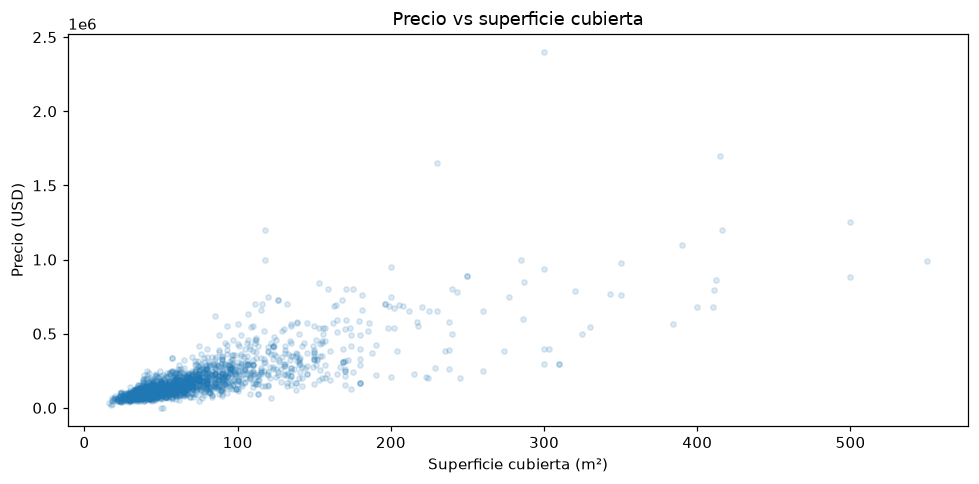

In [11]:
df_plot = df.dropna(subset=["precio_usd", "superficie_cubierta"])
df_plot.plot.scatter(x="superficie_cubierta", y="precio_usd", alpha=0.15, s=12)
plt.xlabel("Superficie cubierta (m²)")
plt.ylabel("Precio (USD)")
plt.title("Precio vs superficie cubierta")
plt.tight_layout()
plt.show()

In [12]:
print("Correlación precio_usd vs superficie_cubierta:")
print(df_plot[["precio_usd", "superficie_cubierta"]].corr().iloc[0, 1])

Correlación precio_usd vs superficie_cubierta:
0.7841025005542412


### 2.4 Ambientes y dormitorios

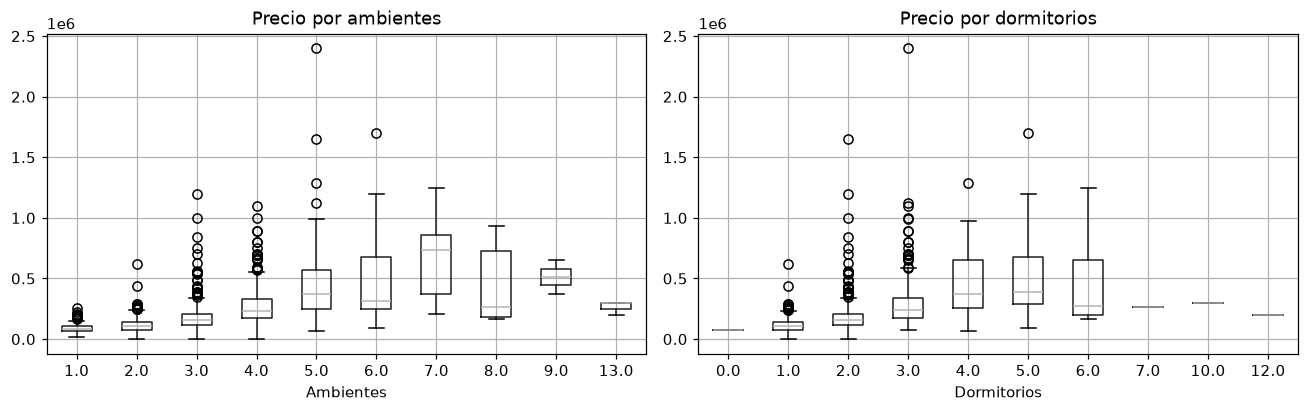

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.dropna(subset=["ambientes"]).boxplot(column="precio_usd", by="ambientes", ax=axes[0])
axes[0].set_title("Precio por ambientes")
axes[0].set_xlabel("Ambientes")

df.dropna(subset=["dormitorios"]).boxplot(column="precio_usd", by="dormitorios", ax=axes[1])
axes[1].set_title("Precio por dormitorios")
axes[1].set_xlabel("Dormitorios")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 2.5 Antigüedad

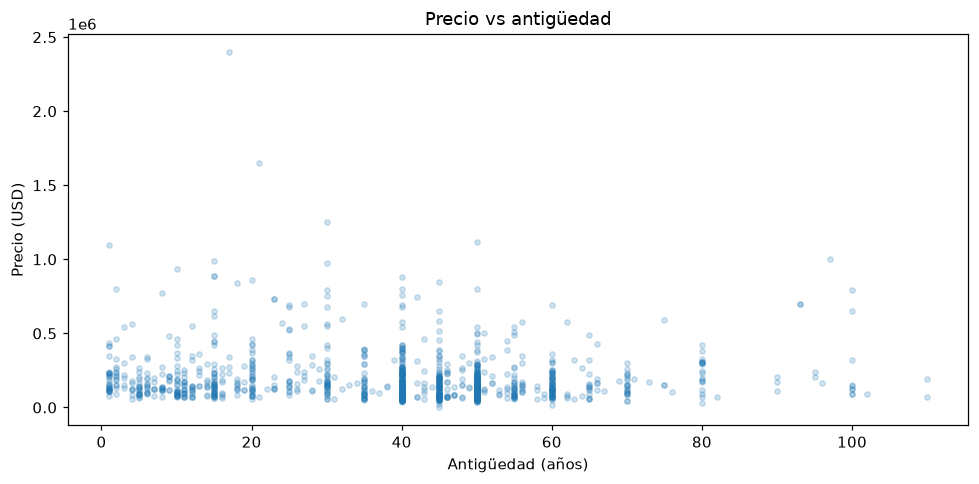

In [14]:
df.dropna(subset=["antiguedad"]).plot.scatter(x="antiguedad", y="precio_usd", alpha=0.2, s=12)
plt.xlabel("Antigüedad (años)")
plt.ylabel("Precio (USD)")
plt.title("Precio vs antigüedad")
plt.tight_layout()
plt.show()

### 2.6 Expensas

Las expensas solo existen en propiedades con administración (principalmente departamentos). Se analiza su relación con el precio sobre el subconjunto informado.

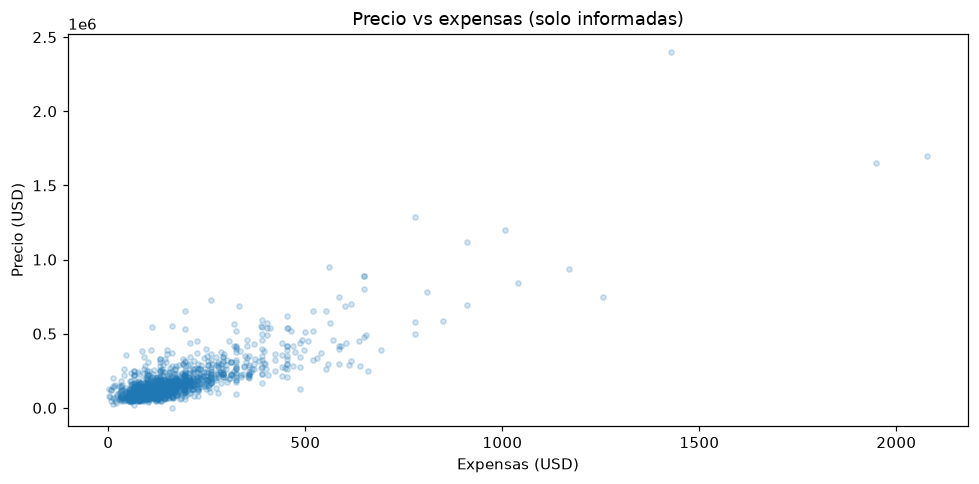

In [15]:
con_expensas = df.dropna(subset=["precio_usd", "expensas_usd"])
con_expensas.plot.scatter(x="expensas_usd", y="precio_usd", alpha=0.2, s=12)
plt.xlabel("Expensas (USD)")
plt.ylabel("Precio (USD)")
plt.title("Precio vs expensas (solo informadas)")
plt.tight_layout()
plt.show()

In [16]:
print(f"Filas con expensas informadas: {len(con_expensas):,}")
print("Correlación precio_usd vs expensas_usd:")
print(con_expensas[["precio_usd", "expensas_usd"]].corr().iloc[0, 1])

Filas con expensas informadas: 1,330
Correlación precio_usd vs expensas_usd:
0.8368215659621882


## 3. Correlaciones entre variables numéricas

In [17]:
columnas = [
    "precio_usd",
    "superficie_cubierta",
    "ambientes",
    "dormitorios",
    "banos",
    "antiguedad",
    "expensas_usd",
]
corr = df[columnas].corr()
corr.round(2)

,precio_usd,superficie_cubierta,ambientes,dormitorios,banos,antiguedad,expensas_usd
precio_usd,1.00,0.78,0.55,0.51,0.68,-0.07,0.84
superficie_cubierta,0.78,1.00,0.76,0.74,0.78,0.13,0.72
ambientes,0.55,0.76,1.00,0.97,0.70,0.24,0.53
dormitorios,0.51,0.74,0.97,1.00,0.68,0.22,0.48
banos,0.68,0.78,0.70,0.68,1.00,0.17,0.68
antiguedad,-0.07,0.13,0.24,0.22,0.17,1.00,-0.06
expensas_usd,0.84,0.72,0.53,0.48,0.68,-0.06,1.00


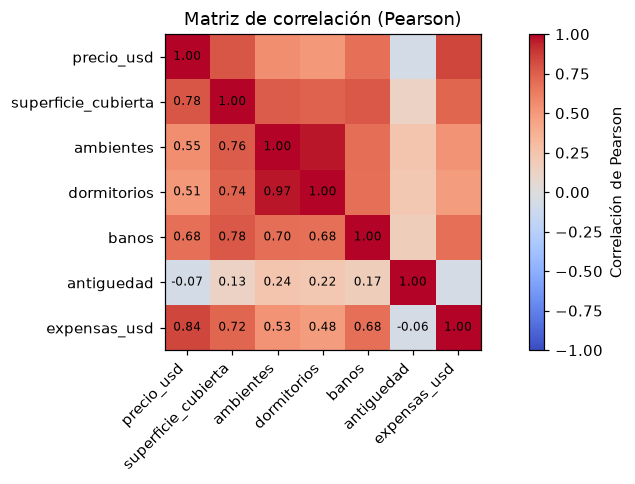

In [18]:
import numpy as np

mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label="Correlación de Pearson")
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mascara[i, j]:
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

## 4. Conclusiones para feature engineering

1. **Target sesgado a la derecha:** `log(precio_usd)` es aproximadamente normal. La fase 4 debería considerar entrenar sobre el logaritmo (o una métrica tipo RMSE en log) por la cola larga de propiedades caras.
2. **Precios inválidos:** existen filas con `precio_usd <= 0` que deben filtrarse o tratarse antes de entrenar.
3. **Barrio con alta señal:** hay una dispersión enorme entre barrios (p. ej. Recoleta/Palermo vs. barrios del oeste). Candidato natural a codificación ordinal por mediana o one-hot con regularización.
4. **Superficie y ambientes:** `superficie_cubierta` correlaciona fuerte con el precio (≈0.8). `ambientes` y `dormitorios` son proxies discretos de tamaño; conviene usarlos como categóricos ordinales.
5. **Expensas:** en el subconjunto informado (66%) correlacionan con el precio; el indicador `expensas_informado` captura el resto de la señal.
6. **Multicolinealidad esperada:** superficie ↔ ambientes ↔ dormitorios están correlacionadas entre sí; los modelos de árbol (XGBoost) toleran esto sin problema.
7. **Antigüedad:** relación no monotónica con el precio; conviene mantenerla numérica y dejar que el modelo la modele.
8. **Columnas a descartar** en features: `cocheras`, `superficie_semicubierta`, `superficie_total` (cobertura < 3%).